# Example-08: Apply window

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.window import Window

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(4096, 'cosine_window', 1.0)


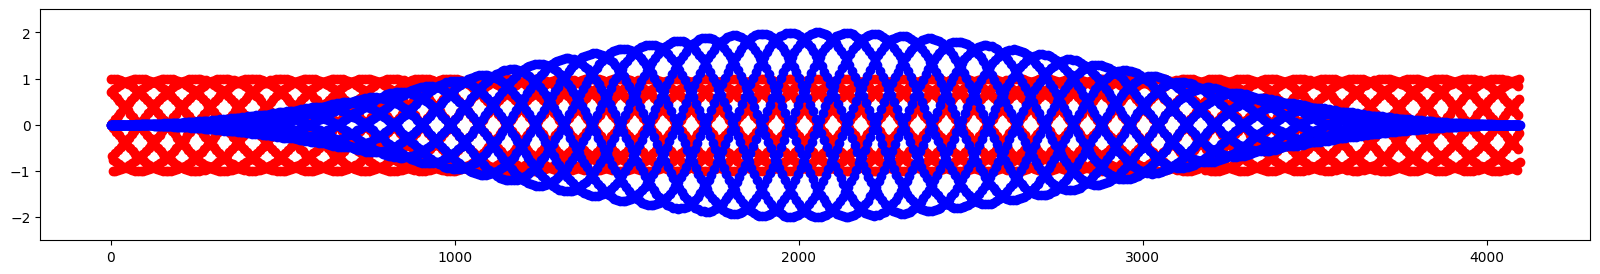

Window(4096, 'kaiser_window', 5.0)


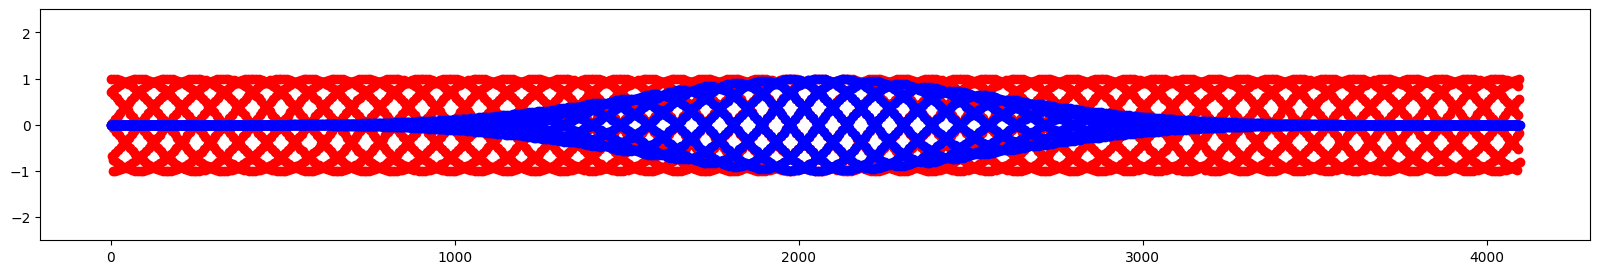

In [3]:
# Apply window to signal and plot result in time domain

# Set test signal

length = 4096
signal = torch.sin(2.0*numpy.pi*0.12345*torch.linspace(0, length, length, dtype=dtype, device=device))


# Set time

t = torch.linspace(0, length, length, dtype=dtype, device=device)

# Set cosine window

w = Window.from_cosine(length, 1.0, dtype=dtype, device=device)
print(w)

# Plot

plt.figure(figsize=(20, 3))
plt.ylim(-2.5, 2.5)
plt.scatter(t.detach().cpu(), signal.detach().cpu(), color='red', marker='o')
plt.scatter(t.detach().cpu(), (signal*w.window).detach().cpu(), color='blue', marker='o')
plt.show()

# Set kaiser window

w = Window.from_kaiser(length, 5.0, dtype=dtype, device=device)
print(w)

# Plot

plt.figure(figsize=(20, 3))
plt.ylim(-2.5, 2.5)
plt.scatter(t.cpu().numpy(), signal.cpu().numpy(), color='red', marker='o')
plt.scatter(t.cpu().numpy(), (signal*w.window).cpu().numpy(), color='blue', marker='o')
plt.show()